# Downloading data

Required conda package install: `pystac-client`, `odc-stac`, `planetary-computer`, `rioxarray`

In [106]:
from pystac_client import Client
import planetary_computer as pc
import odc.stac
import rioxarray as rxr

import matplotlib.pyplot as plt

## Download optical data

In [157]:
# 1. Define Area of Interest (AOI) for Bristol, UK [min_lon, min_lat, max_lon, max_lat]
aoi_name = "bristol"
# bbox = [-2.68, 51.40, -2.50, 51.52]
bbox = [-2.76, 51.38,-2.43,51.53]

daterange = "1996-06-01/1996-08-31"  # summer 1996
# daterange = "2025-12-01/2026-03-28"  # winter
# daterange = "2026-06-01/2026-08-31"  # summer 2026

max_cloud_percent = 20  # maximum cloud cover percentage

# 2. Connect to the USGS STAC API
# stac_url, collection = "https://landsatlook.usgs.gov/stac-server", "landsat-c2l2-sr"
# stac_url, collection = "https://earth-search.aws.element84.com/v1", "landsat-c2-l2"
stac_url, collection = "https://planetarycomputer.microsoft.com/api/stac/v1", "landsat-c2-l2"

catalog = Client.open(stac_url)

In [158]:
# 3. Search for cloud-free Landsat 8/9 Surface Reflectance (c2l2-sr) imagery in Summer
search = catalog.search(
    collections=[collection],
    bbox=bbox,
    datetime=daterange,
    query={
        "eo:cloud_cover": {"lt": max_cloud_percent},  # Cloud cover less than 15%
        "platform": {"in": ["landsat-5", "landsat-8", "landsat-9"]}  # Select specific platforms to exclude landsat-7
        }, 
    sortby=[{"field": "properties.eo:cloud_cover", "direction": "asc"}]
)

items = list(search.items())
print(f"Found {len(items)} matching scene(s).")

Found 4 matching scene(s).


In [ ]:
best_item = items[0]

date = best_item.properties['datetime'][:10]
epsg = best_item.properties['proj:code']
satellite = best_item.properties['platform']

print(f"Selected Scene ID: {best_item.id}")
print(f"Acquisition Date: {best_item.properties['datetime']}")
print(f"Cloud Cover: {best_item.properties['eo:cloud_cover']}%")
print(f"Projection: {best_item.properties['proj:code']}")

Selected Scene ID: LT05_L2SP_203024_19960817_02_T1
Acquisition Date: 1996-08-17T10:20:53.527075Z
Cloud Cover: 15.0%
Projection: EPSG:32630


In [164]:
epsg = best_item.properties['proj:code']

# Load requested bands directly into an xarray.Dataset using odc-stac
# Landsat 8/9 bands: red (Band 4), green (Band 3), blue (Band 2)
ds = odc.stac.load(
    [best_item],
    bands=["red", "green", "blue", "nir08"],  # Include NIR band for NDVI calculation
    bbox=bbox,
    # crs=epsg,  # Use the EPSG code from the best item
    # resolution=30, # Landsat resolution in meters
    patch_url=pc.sign_url,  # Dynamically signs URLs as GDAL fetches chunks
).squeeze()

# set zero to NaN
ds = ds.where(ds > 0)

# Surface reflectance scaling values
ds = ds * 0.0000275 - 0.2  # convert to SR

ds.compute()

ds

<xarray.Dataset> Size: 7MB
Dimensions:      (y: 561, x: 768)
Coordinates:
  * y            (y) float64 4kB 5.709e+06 5.709e+06 ... 5.692e+06 5.692e+06
  * x            (x) float64 6kB 5.167e+05 5.167e+05 ... 5.396e+05 5.397e+05
    spatial_ref  int32 4B 32630
    time         datetime64[ns] 8B 1996-08-17T10:20:53.527075
Data variables:
    red          (y, x) float32 2MB 0.08281 0.08669 0.08669 ... 0.05278 0.04893
    green        (y, x) float32 2MB 0.08034 0.08034 0.08034 ... 0.06219 0.06219
    blue         (y, x) float32 2MB 0.05778 0.05292 0.05778 ... 0.0434 0.03862
    nir08        (y, x) float32 2MB 0.04371 0.04371 0.0483 ... 0.3265 0.3132

In [165]:
rgb.rio.resolution()

(30.0, -30.0)

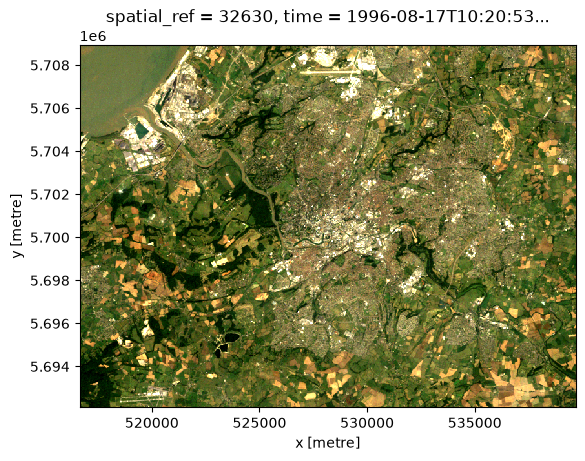

In [166]:
rgb = ds[["red", "green", "blue"]].to_array()

fig, ax = plt.subplots()
rgb.plot.imshow(ax=ax, robust=True)
ax.set_aspect("equal")

In [167]:
# Calculate NDVI

ndvi = (ds["nir08"] - ds["red"]) / (ds["nir08"] + ds["red"])

ndwi = (ds["green"] - ds["nir08"]) / (ds["green"] + ds["nir08"])

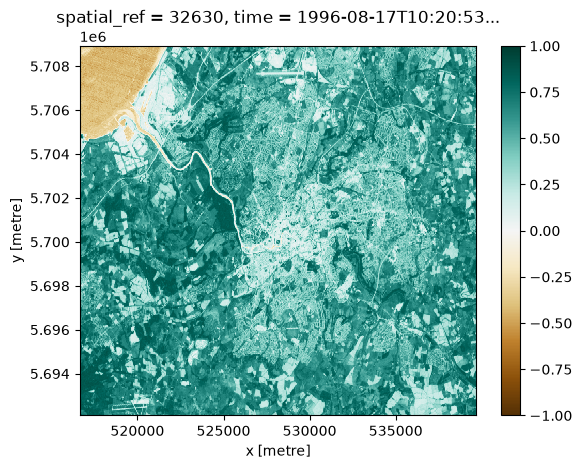

In [168]:
ndvi.plot.imshow(cmap="BrBG", vmin=-1, vmax=1)

# ndwi.plot.imshow(cmap="RdBu", vmin=-1, vmax=1)
# (ndwi>0.0).plot.imshow(cmap="RdBu", vmin=-1, vmax=1)

In [169]:
filename = f"{aoi_name}_{date}_{satellite}.tif"

print('Saving to:', filename)

ds.rio.to_raster(filename, driver="GTiff", compress="deflate")

Saving to: bristol_1996-08-17_landsat-5.tif


In [170]:
ds_loaded = rxr.open_rasterio(filename, masked=True).squeeze()

ds_loaded

<xarray.DataArray (band: 4, y: 561, x: 768)> Size: 7MB
[1723392 values with dtype=float32]
Coordinates:
  * band         (band) int64 32B 1 2 3 4
  * y            (y) float64 4kB 5.709e+06 5.709e+06 ... 5.692e+06 5.692e+06
  * x            (x) float64 6kB 5.167e+05 5.167e+05 ... 5.396e+05 5.397e+05
    spatial_ref  int64 8B 0
Attributes:
    AREA_OR_POINT:  Area
    scale_factor:   1.0
    add_offset:     0.0
    long_name:      ('red', 'green', 'blue', 'nir08')

## Get a DEM instead

In [ ]:
# 1. Define Area of Interest (AOI) for Bristol, UK [min_lon, min_lat, max_lon, max_lat]
aoi_name = "bristol"
# bbox = [-2.68, 51.40, -2.50, 51.52]
bbox = [-2.76, 51.38,-2.43,51.53]


In [171]:
search = catalog.search(
    collections=["cop-dem-glo-30"],
    bbox=bbox,
    # datetime=daterange,
    # query={
    #     "eo:cloud_cover": {"lt": max_cloud_percent},  # Cloud cover less than 15%
    #     "platform": {"in": ["landsat-5", "landsat-8", "landsat-9"]}  # Select specific platforms to exclude landsat-7
    #     }, 
    # sortby=[{"field": "properties.eo:cloud_cover", "direction": "asc"}]
)

items = list(search.items())
print(f"Found {len(items)} matching scene(s).")

Found 1 matching scene(s).


In [172]:
best_item = items[0]

In [174]:
# Load requested bands directly into an xarray.Dataset using odc-stac
# Landsat 8/9 bands: red (Band 4), green (Band 3), blue (Band 2)
dem = odc.stac.load(
    [best_item],
    # bands=["red", "green", "blue", "nir08"],  # Include NIR band for NDVI calculation
    bbox=bbox,
    # crs=epsg,  # Use the EPSG code from the best item
    # resolution=30, # Landsat resolution in meters
    patch_url=pc.sign_url,  # Dynamically signs URLs as GDAL fetches chunks
).squeeze()


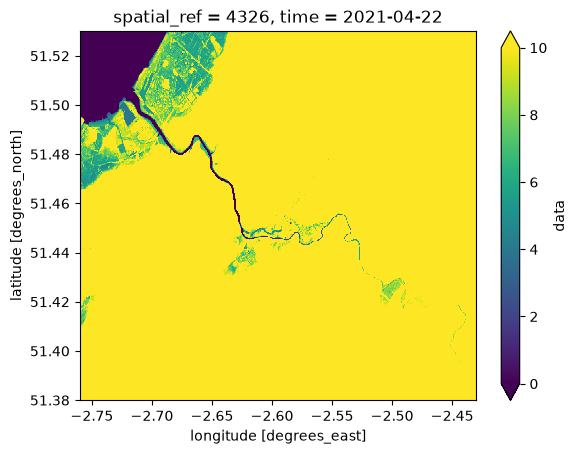

In [178]:
dem.data.plot.imshow(vmin=0, vmax=10)

In [179]:
dem.rio.to_raster(f"{aoi_name}_copdem30.tif", driver="GTiff", compress="deflate")